Step 1: Fetching ACS 2018 data from Census API...
✓ Raw tracts collected: 1,478

Step 2: Creating new variables...
Missing median_rent:   64 tracts (4.3%)
Missing median_value:  39 tracts (2.6%)
Missing median_income: 23 tracts (1.6%)
✓ Variables created. Final dataset: 1,478 tracts

New variables created:
  gentle_density_share : share of 2-3 unit buildings
  high_density_share   : share of 4+ unit buildings
  mf_share             : share of any multifamily housing
  log_rent             : log of median rent (% interpretation)
  log_value            : log of median home value
  treated_dupac        : 1 if tract has above-median density zoning
  bea_monthly_cost     : owner cost imputed at 6.29% of home value / 12
  minority_share       : share of Black + Hispanic population
  poverty_rate         : share of population below poverty line

Step 3: Data cleaning...
Tracts before cleaning: 1,501
Missing log_rent filled with BEA imputation for 64 tracts
Tracts after cleaning: 1,478


,GEOID,median_rent,median_value,mf_share,gentle_density_share,log_rent,log_value,treated_dupac
0,25009205900,1181.0,295600.0,0.5118,0.4604,7.0741,12.5968,1
1,25009206800,733.0,267300.0,0.8725,0.2956,6.5971,12.4961,1
2,25009210300,2060.0,340600.0,0.5778,0.0275,7.6305,12.7385,0
3,25009217600,928.0,576500.0,0.2127,0.0747,6.8330,13.2647,0
4,25009223300,1389.0,511400.0,0.1794,0.0581,7.2363,13.1449,0



Step 4: Creating graphs...


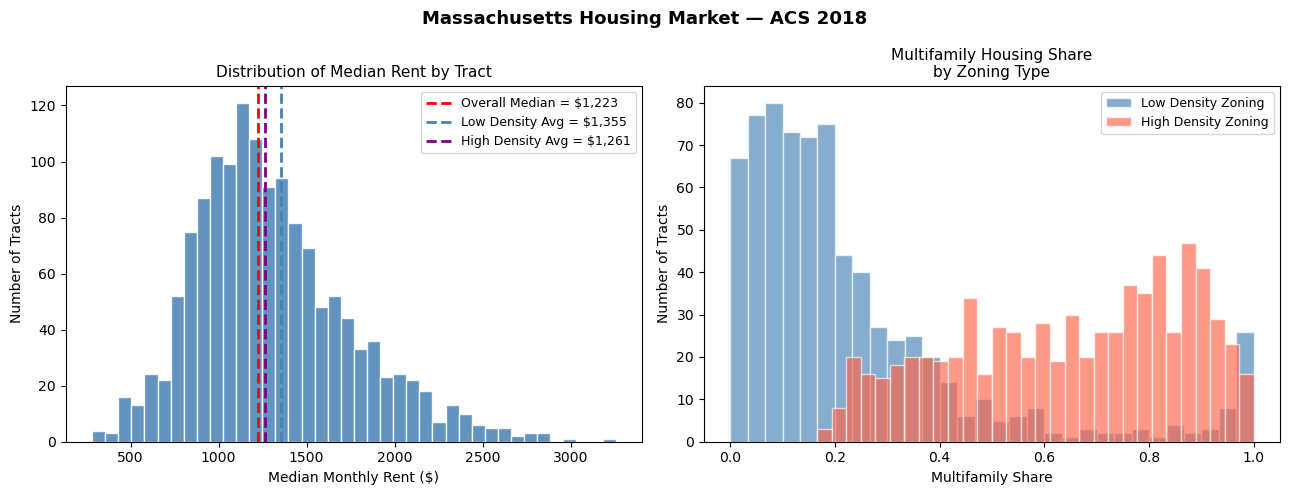

✓ Graphs saved as housing_graphs.png

Step 5: Exporting data for R regressions...
✓ Exported housing_data.csv — 1,478 rows, 16 columns

Columns exported:
  GEOID
  median_rent
  median_value
  median_income
  log_rent
  log_value
  log_income
  mf_share
  gentle_density_share
  high_density_share
  sf_share
  renter_share
  treated_dupac
  minority_share
  poverty_rate
  bea_monthly_cost


In [11]:
# ============================================================
# Housing Affordability — Massachusetts Zoning Analysis
# Data Collection, Cleaning, Variables & Graphs
# ============================================================

import numpy as np
import pandas as pd  #for my excel/spreadsheet tool for tables
import matplotlib.pyplot as plt  #used later to make the 2 histograms 
import requests, zipfile, tempfile, os, warnings    #fetching my data 
from io import BytesIO

warnings.filterwarnings('ignore')   #mute noisy depreciation so that my outputs are clean

# ── 1. DATA FROM CENSUS ACS API ─────────────────────
#For this project I imported data directly from the US Census Bureau's ACS (American Community Survey) API. 
#I built a shopping list of variable codes; each one maps to a specific housing or demographic stat
#then sent a request to their server asking for every census tract in Massachusetts (state code 25).

# Documentation: https://api.census.gov/data.html
# Variables at: https://api.census.gov/data/2018/acs/acs5/variables.html
# State code 25 = Massachusetts, tract:* = all tracts

ACS_VARS = [
    'B25064_001E',  # median gross rent-this is the main affordability outcome I care about
    'B25077_001E',  # median home value- proxy for ownership affordability
    'B19013_001E',  # median household income-i need this to contextualize the rent burden
    'B25003_001E',  # total occupied units-will show as demoninator for renter share
    'B25003_003E',  # renter occupied-this is the numerator of renter share
    'B25024_001E',  # total units in structure
    'B25024_002E',  # 1-unit detached (single family)
    'B25024_003E',  # 1-unit attached (single family)
    'B25024_004E',  # 2-unit buildings  (gentle density)
    'B25024_005E',  # 3-4 unit buildings (gentle density)-duplex/triplex
    'B25024_006E',  # 5-9 unit buildings (high density)-crossing into high density territory
    'B25024_007E',  # 10-19 unit buildings (high density)
    'B25024_008E',  # 20-49 unit buildings (high density)
    'B25024_009E',  # 50+ unit buildings (high density)
    'B02001_001E',  # total population
    'B02001_003E',  # Black/African American population- for equity analysis
    'B03003_003E',  # Hispanic/Latino population- combined for minrity_share
    'B17001_002E',  # below poverty level- povery rate numerator population below powerty line
    'B17001_001E',  # poverty universe
    'NAME'
]

print("Step 1: Fetching ACS 2018 data from Census API...")
base   = 'https://api.census.gov/data/2018/acs/acs5'   #this is the Census Api endpoint for 2018 5-year ACS estimates
params = {'get': ','.join(ACS_VARS), 'for': 'tract:*', 'in': 'state:25', 'key': 'bfb5897fd46863b47e4f41fe694cadbc016d3f7a'}
#what im doing is getting= the variable i want/for= every tract/ in= Massachusetts only (Fips code 25)


r      = requests.get(base, params=params, timeout=90)   #sending api request= timeout of 90 seconds which is waiting for a response
data   = r.json()     #unpack the response (JSON) into python list
acs    = pd.DataFrame(data[1:], columns=data[0])  #make row 0 a header, row 1+ are actual tract data>make it become a table
acs['GEOID'] = acs['state'] + acs['county'] + acs['tract']   
# creates a unique 11-digit ID per tract by concatenating state+county+tract codes ( Census GEOID format)

NUM_VARS = ACS_VARS[:-1]
NUM_VARS

acs[NUM_VARS] = acs[NUM_VARS].astype(float)
acs[NUM_VARS] = acs[NUM_VARS].replace(-666666666, np.nan)
# Census uses -666666666 for missing/suppressed data — replace with NaN

print(f"✓ Raw tracts collected: {len(acs):,}")

# ── 2. CREATE NEW VARIABLES ──────────────────────────────────
#Raw Census columns aren't directly useful for analysis, so I derived all the variables I actually needed; housing type shares, log-transformed outcomes, and a binary treatment indicator for the zoning analysis.

print("\nStep 2: Creating new variables...")

# Housing stock shares
acs['units_gentle'] = acs['B25024_004E'] + acs['B25024_005E']
# gentle density or # B25024_004E = 2-unit + 3-4-unit buildings ( B25024_005E) — combining them gives the "gentle density" stock per tract

acs['units_high']   = (acs['B25024_006E'] + acs['B25024_007E'] +
                        acs['B25024_008E'] + acs['B25024_009E'])
# high density = 5+ unit buildings — larger apartment complexes
## 5-9 + 10-19 + 20-49 + 50+ unit buildings = anything that's clearly an apartment complex


acs['units_sf']     = acs['B25024_002E'] + acs['B25024_003E'] ## 1-unit detached + 1-unit attached
acs['units_mf']     = acs['units_gentle'] + acs['units_high'] # # all multifamily combined
acs['total_units']  = acs['B25024_001E'].replace(0, np.nan) # # 0 → NaN so division doesn't explode

#Converting counts into shares (0-1)
#Raw counts cant be compared across tracts or different-sized so I have to divide each type by total units to get a share
#Number between 0 and 1 (would be what fraction of this tract's housing is x type)

#Note: gentle density in urban policy means-small (small scale)

acs['gentle_density_share'] = acs['units_gentle'] / acs['total_units']   #will give me % of tracts homes that are duplex / small apartments
acs['high_density_share']   = acs['units_high']   / acs['total_units']   #share of large apartment buildings-higher in urban tracts
acs['mf_share']             = acs['units_mf']     / acs['total_units']
# what fraction of a tract's housing is multifamily (all multifamily as a share? This is the key independent variable in the regressions

acs['sf_share']             = acs['units_sf']     / acs['total_units']
# single family share — complement of mf_share (the two roughly add to 1)
acs['renter_share']         = acs['B25003_003E']  / acs['B25003_001E'].replace(0, np.nan)
# renter-occupied ÷ total occupied — tells me how renter-heavy each tract is

# Log outcomes (percentages in regressions) (rent, value, income)
# I renamed the raw Census columns to human-readable names. 
#Then I had to this: some tracts report rent data, but owner-occupied neighborhoods often don't — so I imputed a monthly "housing cost" using BEA method.

acs['median_rent']   = acs['B25064_001E']   #renaming code to something reasonable
acs['median_value']  = acs['B25077_001E']   #median home value
acs['median_income'] = acs['B19013_001E']   #median household income- control variable

# Report missing values before proceeding
print(f"Missing median_rent:   {acs['median_rent'].isna().sum():,} tracts ({acs['median_rent'].isna().mean()*100:.1f}%)")
print(f"Missing median_value:  {acs['median_value'].isna().sum():,} tracts ({acs['median_value'].isna().mean()*100:.1f}%)")
print(f"Missing median_income: {acs['median_income'].isna().sum():,} tracts ({acs['median_income'].isna().mean()*100:.1f}%)")


acs['bea_monthly_cost'] = acs['median_value'] * 0.0629 / 12  
# BEA imputation: multiply home value by 6.29% (standard annual cost rate), divide by 12
# this estimates what a homeowner "effectively pays" monthly — fills in rent for owner-occupied tracts

#Explanation: BEA = Bureau of Economic Analysis. 
#It's a US government agency that estimates the implicit cost of homeownership as a share of home value — the idea being that owning a home has an opportunity cost (you could be renting it out), so I can estimate what a homeowner "effectively pays" monthly.
#6.29% is the annual rate BEA uses for that imputation. So the formula is:
#Take the home's value
#Multiply by 6.29% to get the annual implied housing cost
#Divide by 12 to get monthly
## Used here to fill in housing cost for owner-occupied tracts where no rent data exists.
#The Census only collects rent data for renter-occupied units. So if a tract is mostly homeowners, median_rent comes back as NaN — but that doesn't mean housing is free there, it just means the data doesn't exist in that form.
#If I dropped those tracts, I would be throwing away a huge chunk of Massachusetts as lots of suburban and rural areas are majority owner-occupied. My analysis would be biased toward urban renter-heavy neighborhoods.
#So instead of dropping them, I impute a comparable monthly housing cost using the BEA method, which lets me keep those tracts in the regression with a reasonable estimate of what housing costs there. It's essentially saying I don't have rent, but I can approximate what the housing burden looks like.


#Then I log-transformed all 3 variables. Making it a % change instead of dollar change

acs['log_rent']   = np.where(acs['median_rent'].notna() & (acs['median_rent'] > 0),
                              np.log(acs['median_rent']),   #If actual rent data exists use it 
                              np.log(acs['bea_monthly_cost'].replace(0, np.nan)))    #if not use BEA imputed cost i did before

## np.where = "if condition, do A, else do B" —allows me to fill gaps without losing tracts entirely

acs['log_value']  = np.log(acs['median_value'].replace(0, np.nan))
acs['log_income'] = np.log(acs['median_income'].replace(0, np.nan))

# .replace(0, NaN) before log() because log(0) = -infinity, which breaks everything

# Equity variables
#I created two control variables to account for the racial and economic composition of each tract. 
#Separate zoning effects from pre-existing neighborhood disadvantage.

acs['minority_share'] = ((acs['B02001_003E'] + acs['B03003_003E']) /    #Black population + Hispanic 
                          acs['B02001_001E'].replace(0, np.nan))  #devided by total population

# give a 0-1 share of residents who are Black or Hispanic >>> equity analysis control

acs['poverty_rate']   = acs['B17001_002E'] / acs['B17001_001E'].replace(0, np.nan)
# population below poverty line ÷ total poverty universe = share living in poverty

# Treatment variable — high density zoning (above median density)
#Key variable for my analysis is where I split every Massachusetts tract into two groups: those with above-average gentle density (treated = 1) and those with below-average (treated = 0). This lets me compare rent in denser vs. less dense zoning environments, like a quasi-experiment.
#The reason why I hose (low vs high) rather than 3 tiers is becazse the research question is whether any multifanily zoning affects rent,
#not whather the degree of density matters. For me a binary split maximized statistical power and keeps the treatment veriable interpretable.
#For the future research I would consider deviding into 3 different categories



med_du = acs['gentle_density_share'].median()
# find the statewide median gentle-density share — this becomes the threshold
#Mean would not work as the split would be unequal because data is skewed (more robust)
#Median creates 2 equal groups of tracts regardless of outliers which is making the treated and control group balanced for comparing

acs['treated_dupac'] = (acs['gentle_density_share'] > med_du).astype(int)
# True/False comparison → converted to 1/0 with .astype(int)
# 1 = tract has MORE gentle density than the MA median (the "treated" group)
# 0 = tract has LESS gentle density than the MA median (the "control" group)


print(f"✓ Variables created. Final dataset: {len(acs):,} tracts")
print(f"\nNew variables created:")
print(f"  gentle_density_share : share of 2-3 unit buildings")
print(f"  high_density_share   : share of 4+ unit buildings")
print(f"  mf_share             : share of any multifamily housing")
print(f"  log_rent             : log of median rent (% interpretation)")
print(f"  log_value            : log of median home value")
print(f"  treated_dupac        : 1 if tract has above-median density zoning")
print(f"  bea_monthly_cost     : owner cost imputed at 6.29% of home value / 12")
print(f"  minority_share       : share of Black + Hispanic population")
print(f"  poverty_rate         : share of population below poverty line")


# ── 3. DATA CLEANING ─────────────────────────────────────────
title = "Step 3: Data cleaning..."
print("\n" + "=" * len(title))
print(title)
print("=" * len(title))

print(f"Tracts before cleaning: {len(acs) + acs['log_rent'].isna().sum():,}")
print(f"Missing log_rent filled with BEA imputation for {(acs['median_rent'].isna()).sum():,} tracts")
print(f"Tracts after cleaning: {len(acs):,}")

from IPython.display import display
display(acs[['GEOID', 'median_rent', 'median_value', 'mf_share',
     'gentle_density_share', 'log_rent', 'log_value',
     'treated_dupac']].head(5).round(4))


# ── 4. GRAPHS ────────────────────────────────────────────────
#I made two side-by-side charts to visually inspect the data before running any regressions. 
#One shows how rent is distributed across tracts; the other shows whether zoning type actually correlates with how much multifamily housing exists.


print("\nStep 4: Creating graphs...")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Massachusetts Housing Market — ACS 2018', fontsize=13, fontweight='bold')

#I used a setup of 13x5 inch canva for 2 side by side panels

# Graph 1 — Distribution of median rent
ax1 = axes[0]
ax1.hist(acs['median_rent'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(acs['median_rent'].median(), color='red', lw=2, ls='--',
            label=f"Overall Median = ${acs['median_rent'].median():,.0f}")

low_density_mean  = acs[acs['treated_dupac'] == 0]['median_rent'].mean()
high_density_mean = acs[acs['treated_dupac'] == 1]['median_rent'].mean()
ax1.axvline(low_density_mean,  color='steelblue', lw=2, ls='--', label=f"Low Density Avg = ${low_density_mean:,.0f}")
ax1.axvline(high_density_mean, color='purple', lw=2, ls='--', label=f"High Density Avg = ${high_density_mean:,.0f}")

ax1.set_title('Distribution of Median Rent by Tract', fontsize=11)
ax1.set_xlabel('Median Monthly Rent ($)', fontsize=10)
ax1.set_ylabel('Number of Tracts', fontsize=10)
ax1.legend(fontsize=9)

## First graph is a histogram of rent distribution, red  line marks the median so you can see skew/distribution shape


# Graph 2 — MF share by zoning treatment
ax2 = axes[1]
treated_mf   = acs[acs['treated_dupac'] == 1]['mf_share'].dropna()
untreated_mf = acs[acs['treated_dupac'] == 0]['mf_share'].dropna()
ax2.hist(untreated_mf, bins=30, alpha=0.65, color='steelblue',
         label='Low Density Zoning', edgecolor='white')
ax2.hist(treated_mf,   bins=30, alpha=0.65, color='tomato',
         label='High Density Zoning', edgecolor='white')
ax2.set_title('Multifamily Housing Share\nby Zoning Type', fontsize=11)
ax2.set_xlabel('Multifamily Share', fontsize=10)
ax2.set_ylabel('Number of Tracts', fontsize=10)
ax2.legend(fontsize=9)

#so this is an overlapping histogram: blue is below median density tract, red above median
# alpha= 0.65 both mayers semi transparent so the overlap is visible

plt.tight_layout()
plt.savefig('housing_graphs.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphs saved as housing_graphs.png")

#save the figure in gigh resolution dpi=150 

# ── 5. EXPORT CSV FOR R ──────────────────────────────────────
#Finally, I saved the cleaned dataset to a CSV so I could load it into R for the actual regression analysis. 
#I hand-picked only the columns that matter; no raw Census codes, just the derived variables I'll actually use.


print("\n" + "=" * 55)
print("Step 5: Exporting data for R regressions...")
print("=" * 55)

export_cols = ['GEOID', 'median_rent', 'median_value', 'median_income',
               'log_rent', 'log_value', 'log_income',
               'mf_share', 'gentle_density_share', 'high_density_share',
               'sf_share', 'renter_share', 'treated_dupac',
               'minority_share', 'poverty_rate', 'bea_monthly_cost']

acs[export_cols].to_csv('housing_data.csv', index=False)
print(f"✓ Exported housing_data.csv — {len(acs):,} rows, {len(export_cols)} columns")
print("\nColumns exported:")
for c in export_cols:
    print(f"  {c}")

In [9]:
from IPython.display import Image
Image(url="https://media1.tenor.com/m/1kNkTAQ53oQAAAAC/eyebrow-up-whatever.gif")